# Titanic - Machine Learning from Disaster

#### Path settings

In [123]:
from pathlib import Path
import os

class Config:
    # 環境判定
    IS_KAGGLE = bool(os.getenv("KAGGLE_URL_BASE"))

    # ルート
    ROOT = Path("/kaggle/working") if IS_KAGGLE else Path.cwd()

    # データ
    DATA = Path("/kaggle/input/titanic") if IS_KAGGLE else ROOT / "data/raw"

    # 出力
    OUTPUT = ROOT / "output"
    OUTPUT.mkdir(exist_ok=True)

    # DB
    DB = ROOT / "titanic.duckdb" if IS_KAGGLE else ROOT / "data/db/titanic.duckdb"

    print(ROOT)
    print(DATA)
    print(OUTPUT)
    print(DB)

c:\Git\kaggle\titanic
c:\Git\kaggle\titanic\data\raw
c:\Git\kaggle\titanic\output
c:\Git\kaggle\titanic\data\db\titanic.duckdb


In [124]:
import duckdb
import polars as pl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_width_chars(200)

polars.config.Config

#### CREATE TABLE (train and test)

In [125]:
# DuckDBに接続
conn = duckdb.connect(Config.DB)

def create_train():
    # trainデータをテーブルに
    conn.execute(f"""
        CREATE OR REPLACE TABLE train_tbl AS
        SELECT *
        FROM read_csv_auto('{Config.DATA}/train.csv')
    """)


def create_test():
    # testデータをテーブルに
    conn.execute(f"""
        CREATE OR REPLACE TABLE test_tbl AS
        SELECT *
        FROM read_csv_auto('{Config.DATA}/test.csv')
    """)

create_train()
create_test()

In [126]:
train = conn.table("train_tbl").pl()
test = conn.table("test_tbl").pl()

# まずはデータの行数と列数を確認
print(f"train: {train.shape}")
print(f"test: {test.shape}")

# 表を並べて確認する
display(train.head(), test.head())

train: (891, 12)
test: (418, 11)


PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
i64,i64,i64,str,str,f64,i64,i64,str,f64,str,str
1,0,3,"""Braund, Mr. Owen Harris""","""male""",22.0,1,0,"""A/5 21171""",7.25,null,"""S"""
2,1,1,"""Cumings, Mrs. John Bradley (Fl…","""female""",38.0,1,0,"""PC 17599""",71.2833,"""C85""","""C"""
3,1,3,"""Heikkinen, Miss. Laina""","""female""",26.0,0,0,"""STON/O2. 3101282""",7.925,null,"""S"""
4,1,1,"""Futrelle, Mrs. Jacques Heath (…","""female""",35.0,1,0,"""113803""",53.1,"""C123""","""S"""
5,0,3,"""Allen, Mr. William Henry""","""male""",35.0,0,0,"""373450""",8.05,null,"""S"""


PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
i64,i64,str,str,f64,i64,i64,str,f64,str,str
892,3,"""Kelly, Mr. James""","""male""",34.5,0,0,"""330911""",7.8292,null,"""Q"""
893,3,"""Wilkes, Mrs. James (Ellen Need…","""female""",47.0,1,0,"""363272""",7.0,null,"""S"""
894,2,"""Myles, Mr. Thomas Francis""","""male""",62.0,0,0,"""240276""",9.6875,null,"""Q"""
895,3,"""Wirz, Mr. Albert""","""male""",27.0,0,0,"""315154""",8.6625,null,"""S"""
896,3,"""Hirvonen, Mrs. Alexander (Helg…","""female""",22.0,1,1,"""3101298""",12.2875,null,"""S"""


#### CREATE join data

In [127]:
def create_join_data():
    
    # 結合データをテーブルに
    conn.execute(f"""
        CREATE OR REPLACE TABLE join_data_tbl AS
        ( SELECT
            PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
        FROM train_tbl
        UNION ALL
        SELECT
            PassengerId,NULL as Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
        FROM test_tbl
        )
        """)

create_join_data()

In [128]:
join_data = conn.table("join_data_tbl").pl()

# 結合データのサマリを確認
print(join_data.describe())

shape: (9, 13)
┌────────────┬─────────────┬──────────┬──────────┬─────────────────────────────┬────────┬───────────┬──────────┬──────────┬───────────┬───────────┬───────┬──────────┐
│ statistic  ┆ PassengerId ┆ Survived ┆ Pclass   ┆ Name                        ┆ Sex    ┆ Age       ┆ SibSp    ┆ Parch    ┆ Ticket    ┆ Fare      ┆ Cabin ┆ Embarked │
│ ---        ┆ ---         ┆ ---      ┆ ---      ┆ ---                         ┆ ---    ┆ ---       ┆ ---      ┆ ---      ┆ ---       ┆ ---       ┆ ---   ┆ ---      │
│ str        ┆ f64         ┆ f64      ┆ f64      ┆ str                         ┆ str    ┆ f64       ┆ f64      ┆ f64      ┆ str       ┆ f64       ┆ str   ┆ str      │
╞════════════╪═════════════╪══════════╪══════════╪═════════════════════════════╪════════╪═══════════╪══════════╪══════════╪═══════════╪═══════════╪═══════╪══════════╡
│ count      ┆ 1309.0      ┆ 891.0    ┆ 1309.0   ┆ 1309                        ┆ 1309   ┆ 1046.0    ┆ 1309.0   ┆ 1309.0   ┆ 1309      ┆ 1308.0    ┆ 29

#### 気になったことなどをメモする
- 欠損値　→　年齢、値段、客室、港に欠損値あり。特に客室情報は抜けが多い <br>
　　→　客室情報は抜けが多いから落としてしまった方がいいかも <br>
- 年齢は普通に平均で埋めちゃったらまずそう。なにか他の値を参考にできないか <br>
　　→　MrとかMrsとかついてるので、その平均で埋めれるのでは？もしくは平均と中央値があんまり離れてるならどちらを採用するかも考えたほうがいいかも <br>
- 映画で見たら、お金持ちから助かったっぽいイメージ。チケットの値段からお金持ちかどうかわかるかも？ <br>
　　→　相関を見ておく。ところで、チケット代のminが0円…タダってこと？なんで？従業員？？？ <br>
- 出向した港は、0.15%の欠損だけど、なんとなく生存率には関係ないのでは？ <br>
　　→　相関を見ておく <br>

In [129]:
# 年齢の欠損値埋めるために、MrとかMrsとか抜いてる。ついでにその平均値,
# 中央値も切り捨てで表示。
print(
conn.query("""
SELECT
    trim(split_part(split_part(Name, ',', 2), '.', 1)) AS title,
    ROUND(AVG(Age),1) as avg_age,
    median(Age) as med_age,
    count(CASE WHEN Survived is not null and Age is null then PassengerId end) as train_null_count,
    count(CASE WHEN Survived is null and Age is null then PassengerId end) as test_mnull_count
FROM join_data_tbl
GROUP BY trim(split_part(split_part(Name, ',', 2), '.', 1))
""").pl()
)

shape: (18, 5)
┌──────────────┬─────────┬─────────┬──────────────────┬──────────────────┐
│ title        ┆ avg_age ┆ med_age ┆ train_null_count ┆ test_mnull_count │
│ ---          ┆ ---     ┆ ---     ┆ ---              ┆ ---              │
│ str          ┆ f64     ┆ f64     ┆ i64              ┆ i64              │
╞══════════════╪═════════╪═════════╪══════════════════╪══════════════════╡
│ Miss         ┆ 21.8    ┆ 22.0    ┆ 36               ┆ 14               │
│ the Countess ┆ 33.0    ┆ 33.0    ┆ 0                ┆ 0                │
│ Dona         ┆ 39.0    ┆ 39.0    ┆ 0                ┆ 0                │
│ Ms           ┆ 28.0    ┆ 28.0    ┆ 0                ┆ 1                │
│ Mrs          ┆ 37.0    ┆ 35.5    ┆ 17               ┆ 10               │
│ Lady         ┆ 48.0    ┆ 48.0    ┆ 0                ┆ 0                │
│ Col          ┆ 54.0    ┆ 54.5    ┆ 0                ┆ 0                │
│ Don          ┆ 40.0    ┆ 40.0    ┆ 0                ┆ 0                │
│ Mr      

In [130]:
# title   

In [131]:
# EmbarkedのNULLチェック
conn.sql("""
SELECT
    Embarked,
    count(PassengerId)
FROM join_data_tbl
GROUP BY Embarked
""").show()

┌──────────┬────────────────────┐
│ Embarked │ count(PassengerId) │
│ varchar  │       int64        │
├──────────┼────────────────────┤
│ NULL     │                  2 │
│ C        │                270 │
│ Q        │                123 │
│ S        │                914 │
└──────────┴────────────────────┘



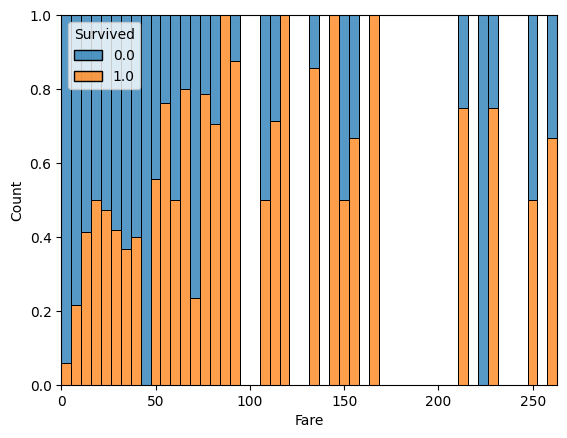

In [132]:
# チケット価格ごとの生存を確認
join_data_pd = join_data.to_pandas()

sns.histplot(
    data=join_data_pd[join_data_pd["Fare"] < 300],
    x="Fare",
    hue="Survived",
    bins=50,
    multiple="fill"
)

plt.show()

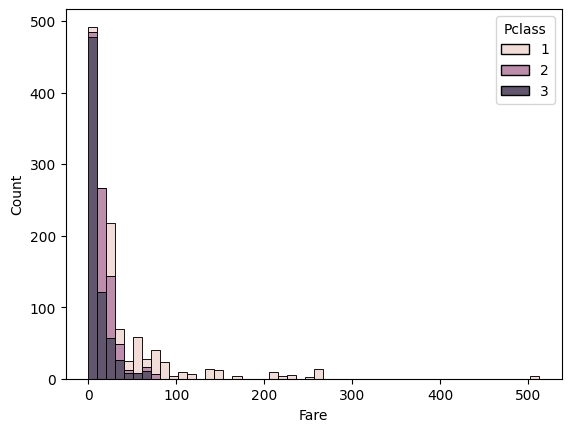

In [133]:
# チケット価格ごとのPclassを確認

sns.histplot(
    join_data,
    x="Fare",
    hue="Pclass",
    bins=50,
    multiple="stack" #人数で確認
)

plt.show()

C:\Users\akai_\AppData\Local\Temp\ipykernel_26420\2476036140.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


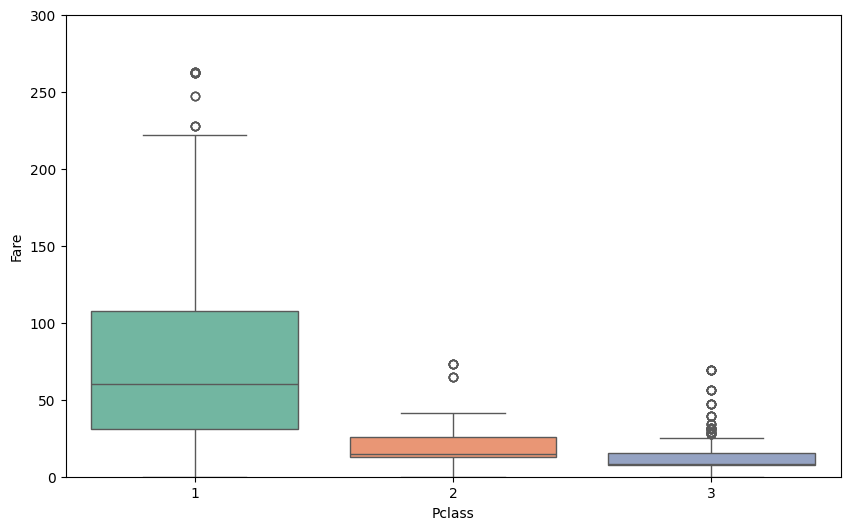

In [134]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=join_data,
    x="Pclass",
    y="Fare",
    palette="Set2"
)
plt.ylim(0, 300) # 300以上は除外
plt.show()

In [135]:
# 値段NULLを埋めるためにテーブル確認する
print(conn.sql("""
SELECT
    *
FROM full_data_tbl
WHERE Fare IS NULL
"""))

# Pclass 3 でNULLなので
print(conn.sql("""
SELECT
    MIN(Fare),
    MAX(Fare),
    avg(Fare),
    median(Fare)
FROM full_data_tbl
WHERE Pclass = 3 AND Fare <> 0
"""))

┌─────────────┬──────────┬────────┬─────────┬─────────┬───────┬───────┬───────┬───────┬─────────┬───────┬─────────────┬────────────┬────────────┬────────────┐
│ PassengerId │ Survived │ Pclass │  Name   │  title  │  Sex  │  Age  │ SibSp │ Parch │ Ticket  │ Fare  │ family_size │ embarked_C │ embarked_Q │ embarked_S │
│    int64    │  int64   │ int64  │ varchar │ varchar │ int32 │ int32 │ int64 │ int64 │ varchar │ int32 │    int64    │   int32    │   int32    │   int32    │
└─────────────┴──────────┴────────┴─────────┴─────────┴───────┴───────┴───────┴───────┴─────────┴───────┴─────────────┴────────────┴────────────┴────────────┘
                                                                            0 rows                                                                          

┌───────────┬───────────┬────────────────────┬──────────────┐
│ min(Fare) │ max(Fare) │     avg(Fare)      │ median(Fare) │
│   int32   │   int32   │       double       │    double    │
├───────────┼───────

In [136]:
# 性別を1/0にする　"male"=1　"female"=0
# 年齢はintにする
# Embarked ワンホットエンコーディング(NULLは一番多いSで埋める)
# Cabin　除外
# 料金はPclassの中央値で補完
conn.execute("""
CREATE OR REPLACE TABLE full_data_tbl AS
WITH title_master AS (
    SELECT 
        trim(split_part(split_part(Name, ',', 2), '.', 1)) AS title_name,
        median(Age) as med_age
    FROM join_data_tbl
    GROUP BY 1
)
SELECT 
    J.PassengerId,
    J.Survived,
    J.Pclass,
    J.Name,
    T.title_name AS title,
    CASE WHEN J.Sex = 'male' THEN 1 ELSE 0 END AS Sex,
    CAST(COALESCE(J.Age, T.med_age) AS INT) AS Age,
    J.SibSp,
    J.Parch,
    J.Ticket,
    CAST(COALESCE(J.Fare, 8) AS INT) AS Fare,
    J.SibSp + J.Parch + 1 AS family_size,
    CASE WHEN J.Embarked = 'C' THEN 1 ELSE 0 END AS embarked_C,
    CASE WHEN J.Embarked = 'Q' THEN 1 ELSE 0 END AS embarked_Q,
    CASE WHEN J.Embarked = 'S' OR J.Embarked IS NULL THEN 1 ELSE 0 END AS embarked_S
FROM 
    join_data_tbl AS J
LEFT JOIN 
    title_master AS T 
    ON trim(split_part(split_part(J.Name, ',', 2), '.', 1)) = T.title_name
""")

In [137]:
full_data = conn.table("full_data_tbl").pl()

# 結合データのサマリを確認（NULL埋まったか）
print(full_data.describe())

shape: (9, 16)
┌────────────┬─────────────┬──────────┬──────────┬────────────────┬──────────┬──────────┬───────────┬──────────┬──────────┬───────────┬───────────┬─────────────┬────────────┬────────────┬────────────┐
│ statistic  ┆ PassengerId ┆ Survived ┆ Pclass   ┆ Name           ┆ title    ┆ Sex      ┆ Age       ┆ SibSp    ┆ Parch    ┆ Ticket    ┆ Fare      ┆ family_size ┆ embarked_C ┆ embarked_Q ┆ embarked_S │
│ ---        ┆ ---         ┆ ---      ┆ ---      ┆ ---            ┆ ---      ┆ ---      ┆ ---       ┆ ---      ┆ ---      ┆ ---       ┆ ---       ┆ ---         ┆ ---        ┆ ---        ┆ ---        │
│ str        ┆ f64         ┆ f64      ┆ f64      ┆ str            ┆ str      ┆ f64      ┆ f64       ┆ f64      ┆ f64      ┆ str       ┆ f64       ┆ f64         ┆ f64        ┆ f64        ┆ f64        │
╞════════════╪═════════════╪══════════╪══════════╪════════════════╪══════════╪══════════╪═══════════╪══════════╪══════════╪═══════════╪═══════════╪═════════════╪════════════╪═══════

In [138]:
# 相関を見ておく
full_data = conn.table("full_data_tbl").pl()

print(full_data.select(
    pl.corr("Sex", "Survived"),
    pl.corr("Age", "Survived"),
    
    pl.corr("Pclass", "Survived"),
    pl.corr("Fare", "Survived"),


    pl.corr("embarked_C", "Survived"),
    pl.corr("embarked_Q", "Survived"),
    pl.corr("embarked_S", "Survived"),

    pl.corr("SibSp", "Survived"),
    pl.corr("Parch", "Survived"),
    pl.corr("family_size", "Survived")
)
)

shape: (1, 10)
┌───────────┬───────────┬───────────┬──────────┬────────────┬────────────┬────────────┬───────────┬──────────┬─────────────┐
│ Sex       ┆ Age       ┆ Pclass    ┆ Fare     ┆ embarked_C ┆ embarked_Q ┆ embarked_S ┆ SibSp     ┆ Parch    ┆ family_size │
│ ---       ┆ ---       ┆ ---       ┆ ---      ┆ ---        ┆ ---        ┆ ---        ┆ ---       ┆ ---      ┆ ---         │
│ f64       ┆ f64       ┆ f64       ┆ f64      ┆ f64        ┆ f64        ┆ f64        ┆ f64       ┆ f64      ┆ f64         │
╞═══════════╪═══════════╪═══════════╪══════════╪════════════╪════════════╪════════════╪═══════════╪══════════╪═════════════╡
│ -0.543351 ┆ -0.070467 ┆ -0.338481 ┆ 0.257088 ┆ 0.16824    ┆ 0.00365    ┆ -0.149683  ┆ -0.035322 ┆ 0.081629 ┆ 0.016639    │
└───────────┴───────────┴───────────┴──────────┴────────────┴────────────┴────────────┴───────────┴──────────┴─────────────┘


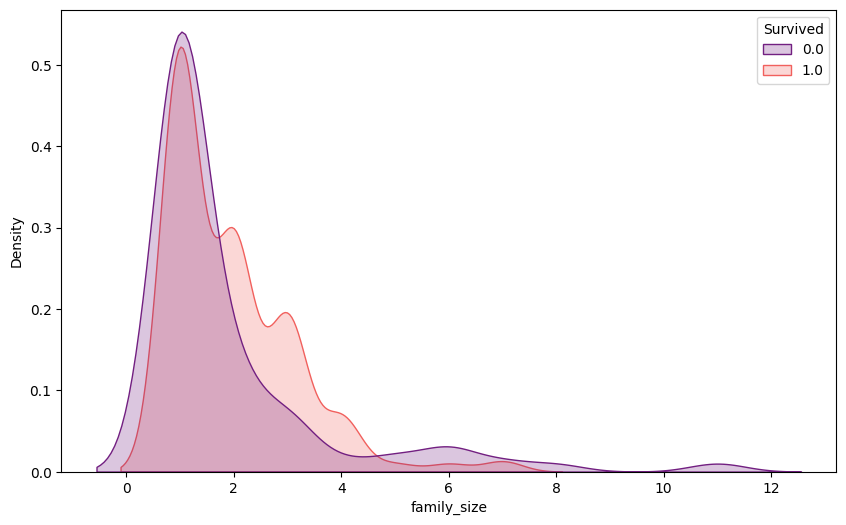

In [139]:
# family_sizeほんとにあんまり相関ない？
plt.figure(figsize=(10, 6))
sns.kdeplot(data=full_data, x="family_size", hue="Survived", fill=True, common_norm=False, palette="magma")
plt.show()

In [ ]:
# やっぱ関係ありそうな気がするので、3グループに分ける
conn.execute("""
UPDATE full_data_tbl
    SET family_size = CASE WHEN family_size = 1 THEN 1
                        WHEN family_size BETWEEN 2 AND 7 THEN 2
                        ELSE 3 END
    """)

# 相関を見ておく
full_data = conn.table("full_data_tbl").pl()

print(full_data.select(
    pl.corr("family_size", "Survived")
)
)

shape: (1, 1)
┌─────────────┐
│ family_size │
│ ---         │
│ f64         │
╞═════════════╡
│ 0.168913    │
└─────────────┘


In [141]:
conn.close()